# AI-POWERED-BANKING-FRAUD-DECTECTION ANALYSIS

# 1. Overview

NexaBank is a modern, technology-first financial institution committed to delivering secure, seamless, and intelligent banking experiences to its customers. Operating across digital channels - mobile, web, and ATM. NexaBank serves a diverse global customer base processing millions of transactions daily. As the bank scales rapidly, safeguarding customers from financial fraud has become one of its highest strategic priorities.

## 1.1 Business Understanding

The global banking industry loses hundreds of billions of dollars annually to fraudulent transactions. As digital payments grow, driven by mobile banking, e-commerce, and real-time transfers, so too does the sophistication of fraud. NexaBank's existing rule-based detection systems are no longer sufficient. They are slow to adapt, generate excessive false alerts, and miss novel fraud patterns that fall outside predefined rules, putting customers and the bank at growing risk.

## 1.2 Business Problem

NexaBank faces a dual challenge: detecting fraudulent transactions accurately and in real time, while ensuring that legitimate customers experience no unnecessary friction. Every undetected fraud transaction results in direct financial loss and erodes customer trust. Every legitimate transaction incorrectly blocked damages the customer relationship and risks churn. Manual review processes at NexaBank cannot operate at the speed and scale demanded by modern digital banking. M y Mission as a data scientist is to leverage AI and machine learning to build an intelligent, scalable fraud detection system for NexaBank that protects customers and the institution from fraudulent transactions — enabling real-time intervention, reducing financial losses, and preserving the trust that is at the heart of everything NexaBank does.

## 1.3 Objectives

1. To identify and prevent fraud in real time
2. To protect customers without disrupting their experience
3. To build model and deliver insights that drive smarter decsions

## 1.4 Research Questions

1. What transaction characteristics are most strongly associated with fraudulent activity in NexaBank's transaction data?
2. Which machine learning algorithm delivers the best performance for fraud detection on NexaBank's dataset?
3. Which features contribute most to the model's predictions, and what actionable insights do they reveal for NexaBank's fraud and risk teams?

## 1.5 Success Metrics

### Model performance
- ROC-AUC score ≥ 0.90 on the test set
- Recall (fraud class) ≥ 0.85 — catch at least 85% of all fraudulent transactions
- Precision ≥ 0.75 — limit false alerts to protect customer experience
- F1-score ≥ 0.80 — balance between precision and recall

### Business impact
- Reduction in false positives compared to NexaBank's current rule-based system
- Fraudulent transactions flagged before funds are transferred (real-time threshold < 100ms)

# 2. Data Understanding

This section explores the NexaBank transaction dataset to understand its structure, 
key variables, and underlying patterns that may distinguish fraudulent transactions 
from legitimate ones.

## 2.1  Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

## 2.1 Loading the Dataset

In [2]:
bf = pd.read_csv(r"C:/Users/Admin/Documents/flatiron/flatiron/WINNIE_PROJECTS/Banking_Fraud_Dataset.csv")

## 2.1 Previewing Dataset

In [3]:
bf

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,16,740,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,5,848,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,2,616,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,9,437,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,15,494,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,439,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,4,738,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,18,649,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,10,838,1,1


In [4]:
# Describe the DataFrame
bf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        10000 non-null  object 
 1   Customer_ID           10000 non-null  object 
 2   Transaction_Amount    10000 non-null  float64
 3   Transaction_Type      10000 non-null  object 
 4   Transaction_Location  10000 non-null  object 
 5   Transaction_Time      10000 non-null  object 
 6   Device_Used           10000 non-null  object 
 7   Account_Age           10000 non-null  int64  
 8   Credit_Score          10000 non-null  int64  
 9   Previous_Fraud        10000 non-null  int64  
 10  Is_Fraud              10000 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 859.5+ KB


In [5]:
# Describe the  data
bf.describe()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,4997.492361,10.646900,578.66280,0.501700,0.283800
std,2914.985459,5.760186,158.73193,0.500022,0.450863
min,10.890000,1.000000,300.00000,0.000000,0.000000
25%,2469.642500,6.000000,442.00000,0.000000,0.000000
50%,4985.325000,11.000000,581.00000,1.000000,0.000000
75%,7557.885000,16.000000,715.00000,1.000000,1.000000
max,9999.290000,20.000000,850.00000,1.000000,1.000000


## 2.3 Data preparation 

This section prepares the NexaBank dataset for modelling by converting data types, 
extracting meaningful features from date and location columns, encoding categorical 
variables, and dropping columns that are not useful for prediction.

### 2.3.1 Datetime connversion

In [6]:
# Convert Transaction_Time from object to datetime
bf['Transaction_Time'] = pd.to_datetime(bf['Transaction_Time'], dayfirst=True)

In [7]:
# Extract useful features from Transaction_Time
bf['Hour'] = bf['Transaction_Time'].dt.hour
bf['Day_of_Week'] = bf['Transaction_Time'].dt.dayofweek

### 2.3.2 Excating necessary columns and dropping irrelevant columns

In [8]:
# Extract Country from Transaction_Location
bf['Country'] = bf['Transaction_Location'].apply(lambda x: x.split(',')[-1].strip())

In [9]:
# 4. Drop columns not needed for modelling
bf.drop(columns=['Transaction_ID', 'Customer_ID', 'Transaction_Time', 'Transaction_Location'], inplace=True)

In [10]:
# Check missing values
print("Missing Values:")
print(bf.isnull().sum())

# Check duplicates
print(f"\nNumber of duplicate rows: {bf.duplicated().sum()}")

Missing Values:
Transaction_Amount    0
Transaction_Type      0
Device_Used           0
Account_Age           0
Credit_Score          0
Previous_Fraud        0
Is_Fraud              0
Hour                  0
Day_of_Week           0
Country               0
dtype: int64

Number of duplicate rows: 0


### 2.3.3 checking outliers

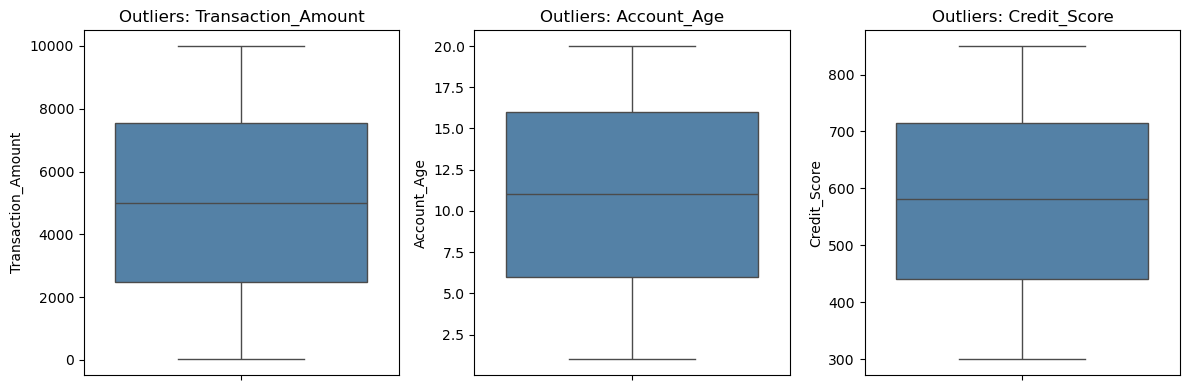

       Transaction_Amount   Account_Age  Credit_Score
count        10000.000000  10000.000000   10000.00000
mean          4997.492361     10.646900     578.66280
std           2914.985459      5.760186     158.73193
min             10.890000      1.000000     300.00000
25%           2469.642500      6.000000     442.00000
50%           4985.325000     11.000000     581.00000
75%           7557.885000     16.000000     715.00000
max           9999.290000     20.000000     850.00000


In [11]:
# Boxplots for numerical columns
numerical_cols = ['Transaction_Amount', 'Account_Age', 'Credit_Score']

plt.figure(figsize=(12, 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=bf[col], color='steelblue')
    plt.title(f'Outliers: {col}')
plt.tight_layout()
plt.show()

# Statistical summary to confirm
print(bf[numerical_cols].describe())

### Outlier Check

The boxplots reveal no extreme outliers across the three numerical features:

- **Transaction_Amount** ranges from 10.89 to 9,999.29 with a mean of ~4,997 — 
  evenly spread across the full range, indicating a uniformly distributed dataset.
- **Account_Age** ranges from 1 to 20 years with a median of 11 — 
  well balanced with no unusual values.
- **Credit_Score** ranges from 300 to 850 with a median of 581 — 
  consistent with a standard credit scoring scale.

No outlier treatment is required. The dataset is clean and ready for EDA.

## 2.4 Exploratory Data Analysis

This section explores the NexaBank dataset guided by the three research questions 
to uncover patterns and relationships that distinguish fraudulent transactions from 
legitimate ones.

## Q1: What transaction characteristics are most strongly associated with fraudulent activity?

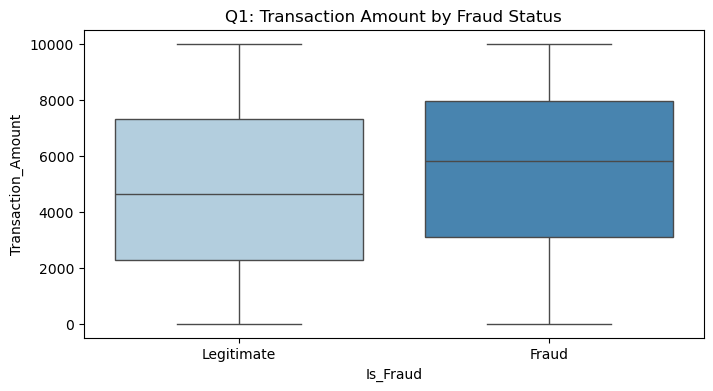

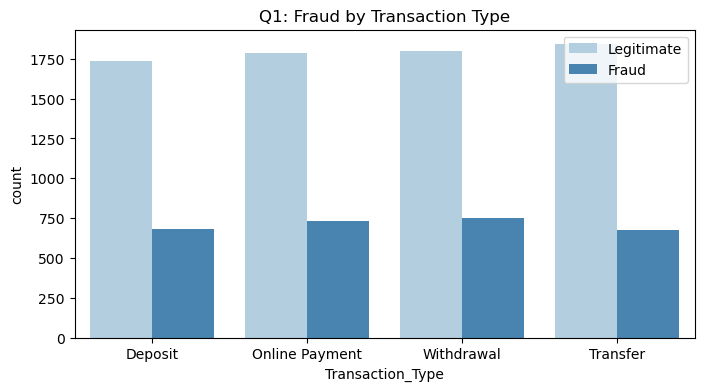

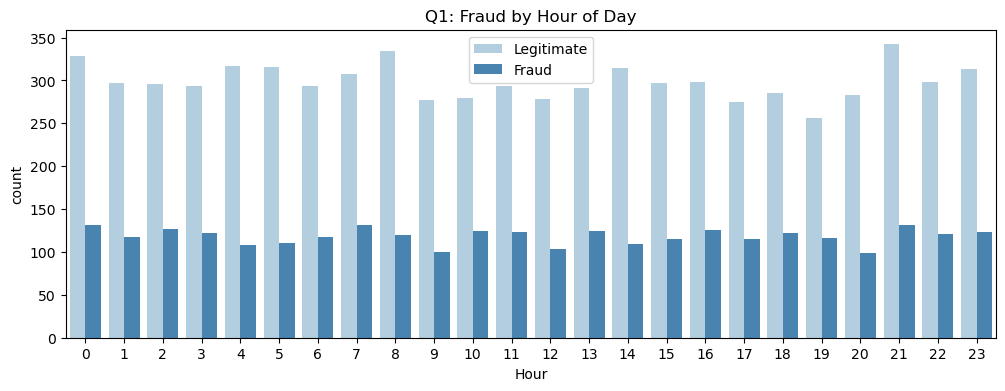

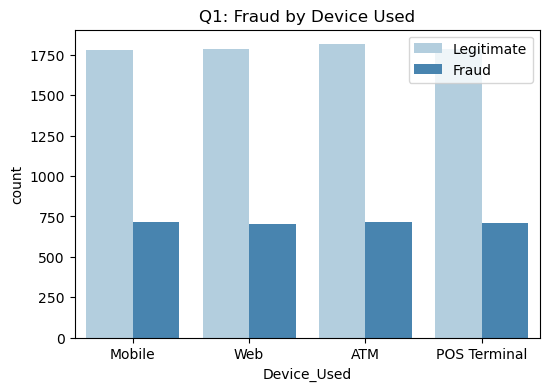

In [12]:
# Transaction Amount by Fraud Status
plt.figure(figsize=(8,4))
sns.boxplot(x='Is_Fraud', data=bf, y='Transaction_Amount', palette='Blues')
plt.title('Q1: Transaction Amount by Fraud Status')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

# Fraud by Transaction Type
plt.figure(figsize=(8,4))
sns.countplot(x='Transaction_Type', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('Q1: Fraud by Transaction Type')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# Fraud by Hour of Day
plt.figure(figsize=(12,4))
sns.countplot(x='Hour', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('Q1: Fraud by Hour of Day')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# Fraud by Device Used
plt.figure(figsize=(6,4))
sns.countplot(x='Device_Used', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('Q1: Fraud by Device Used')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# NOTE: 
- Fraudulent transactions tend to involve higher amounts than legitimate ones, 
  making transaction amount a key fraud indicator.
- Fraud is present across all transaction types, with Deposits and Withdrawals 
  showing a slightly higher proportion of fraudulent activity.
- Fraud occurs consistently across all hours of the day, suggesting that time 
  alone is not a strong predictor of fraud.
- Fraud is spread evenly across all devices — Mobile, Web, ATM, and POS Terminal 
  — meaning device type is not a strong standalone fraud signal.

 ## Q2: Which machine learning algorithm delivers the best performance?

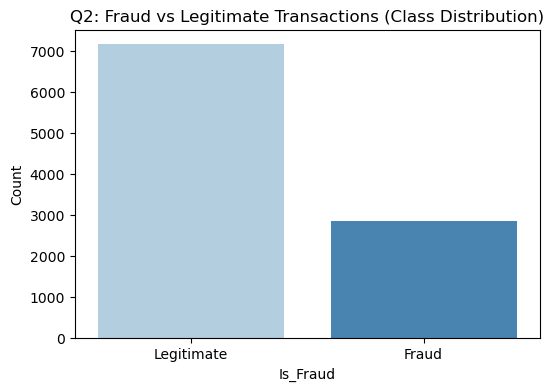

Is_Fraud
0    71.62
1    28.38
Name: proportion, dtype: float64


In [13]:
# Class Distribution — understanding the imbalance before modelling
plt.figure(figsize=(6,4))
sns.countplot(x='Is_Fraud', data=bf, palette='Blues')
plt.title('Q2: Fraud vs Legitimate Transactions (Class Distribution)')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.ylabel('Count')
plt.show()

print(bf['Is_Fraud'].value_counts(normalize=True) * 100)

## NOTE:
- The dataset is imbalanced with 71.62% legitimate and 28.38% fraudulent 
  transactions, meaning SMOTE will be applied during modelling to prevent 
  the model from being biased towards the majority class.

## Q3: Which features contribute most to the model's predictions?

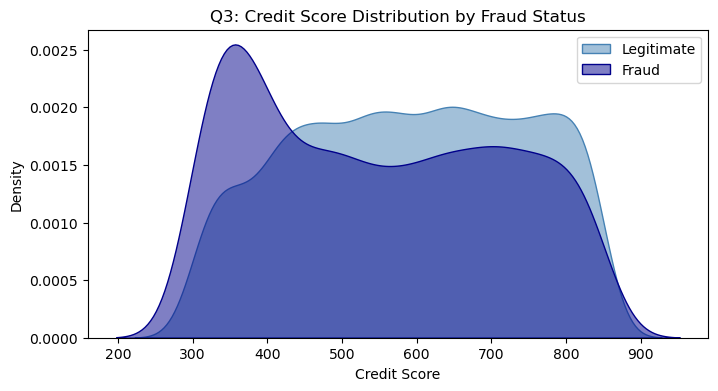

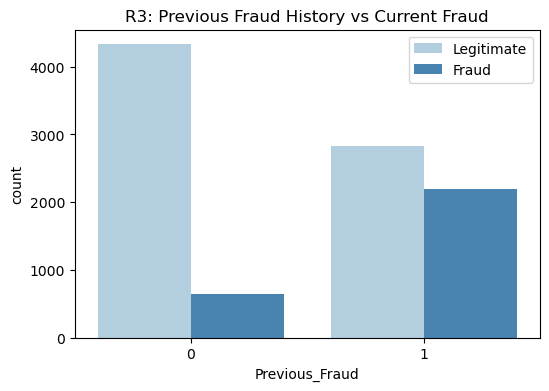

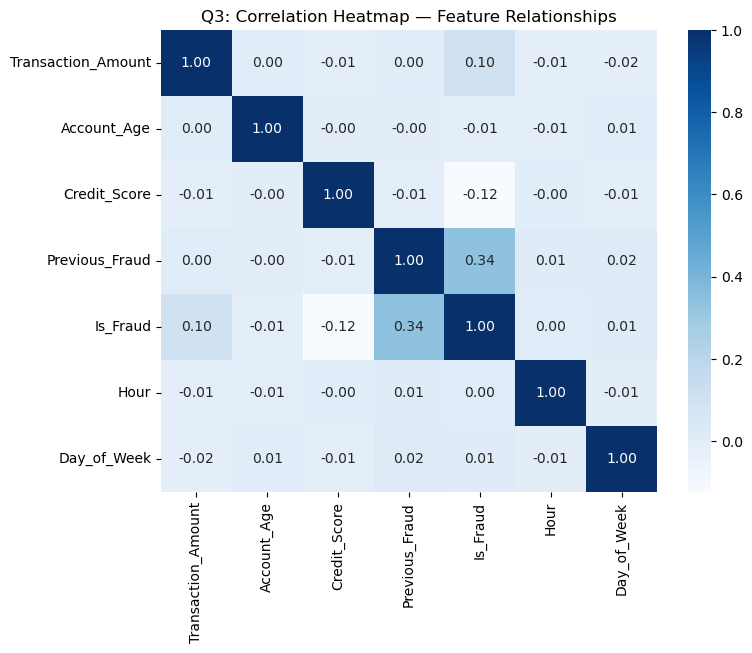

In [14]:
# Credit Score by Fraud Status — Normal Distribution
plt.figure(figsize=(8,4))
sns.kdeplot(data=bf[bf['Is_Fraud']==0], x='Credit_Score', 
            label='Legitimate', fill=True, color='steelblue', alpha=0.5)
sns.kdeplot(data=bf[bf['Is_Fraud']==1], x='Credit_Score', 
            label='Fraud', fill=True, color='darkblue', alpha=0.5)
plt.title('Q3: Credit Score Distribution by Fraud Status')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.show()

# Previous Fraud History
plt.figure(figsize=(6,4))
sns.countplot(x='Previous_Fraud', hue='Is_Fraud', data=bf, palette='Blues')
plt.title('R3: Previous Fraud History vs Current Fraud')
plt.legend(['Legitimate', 'Fraud'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(bf.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Q3: Correlation Heatmap — Feature Relationships')
plt.show()

# NOTE:
- Fraudulent transactions are more concentrated among customers with lower 
  credit scores (below 400), suggesting that credit score is a meaningful 
  indicator of fraud risk at NexaBank.
- Customers with no prior fraud history (Previous_Fraud = 0) account for the 
  majority of transactions, however customers with a prior fraud flag 
  (Previous_Fraud = 1) show a significantly higher proportion of current fraud, 
  making previous fraud history the strongest single predictor in the dataset.
- The correlation heatmap confirms that Previous_Fraud has the highest 
  correlation with Is_Fraud (0.34), followed by Transaction_Amount (0.10) 
  and Credit_Score (-0.12), indicating these three features will likely 
  contribute most to the model's predictions.

# 3. Data Preprocessing

This section prepares the NexaBank dataset for modelling by encoding categorical 
variables, scaling numerical features, and addressing class imbalance using SMOTE.

## 3.1 Encoding Data

In [15]:
le = LabelEncoder()
bf['Transaction_Type'] = le.fit_transform(bf['Transaction_Type'])
bf['Device_Used'] = le.fit_transform(bf['Device_Used'])
bf['Country'] = le.fit_transform(bf['Country'])

## 3.2 Defining Feature and Target

In [16]:
X = bf.drop(columns=['Is_Fraud'])
y = bf['Is_Fraud']

## 3.3 Trainig test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
#SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [20]:
# Confirm class balance after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train).value_counts())

Class distribution after SMOTE:
Is_Fraud
0    5751
1    5751
Name: count, dtype: int64


# NOTE:
After applying SMOTE, both classes are perfectly balanced with 5,751 samples 
each, ensuring the model learns fraud patterns equally without being biased 
towards legitimate transactions.

# 4. Modelling

This section trains and compares three machine learning models — Logistic 
Regression, Random Forest, and XGBoost — to identify the best performing 
algorithm for fraud detection on NexaBank's dataset.

## 4.1 Logistic Regression

In [23]:
# Logistic Regression fitting
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [24]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [25]:
# Evaluation
print("Logistic Regression Results:")
print("------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print("------------------------------")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
------------------------------
Accuracy:  0.6715
Precision: 0.4639
Recall:    0.7419
F1 Score:  0.5709
ROC-AUC:   0.7399
------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73      1411
           1       0.46      0.74      0.57       589

    accuracy                           0.67      2000
   macro avg       0.66      0.69      0.65      2000
weighted avg       0.74      0.67      0.69      2000



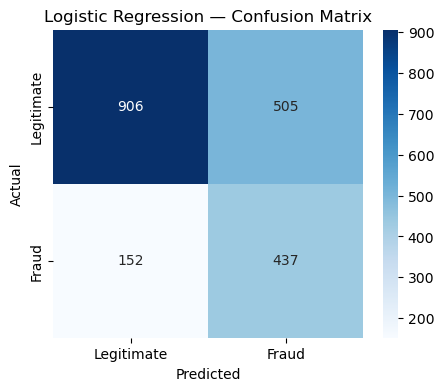

In [26]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', 
            cmap='Blues', xticklabels=['Legitimate', 'Fraud'], 
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# NOTE:
Logistic Regression achieved an accuracy of 67.15% and a ROC-AUC of 0.74, 
correctly identifying 74% of fraudulent transactions (Recall) but with a low 
precision of 46.39%, meaning it generated a high number of false positives — 
flagging 505 legitimate transactions as fraud — making it a weak standalone 
model for NexaBank's fraud detection needs.

## 4.2 Random Forest

In [28]:
# Random Forest fitting
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [29]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [30]:
print("Random Forest Results:")
print("------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print("------------------------------")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
------------------------------
Accuracy:  0.7000
Precision: 0.4899
Recall:    0.4550
F1 Score:  0.4718
ROC-AUC:   0.7211
------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1411
           1       0.49      0.46      0.47       589

    accuracy                           0.70      2000
   macro avg       0.63      0.63      0.63      2000
weighted avg       0.69      0.70      0.70      2000



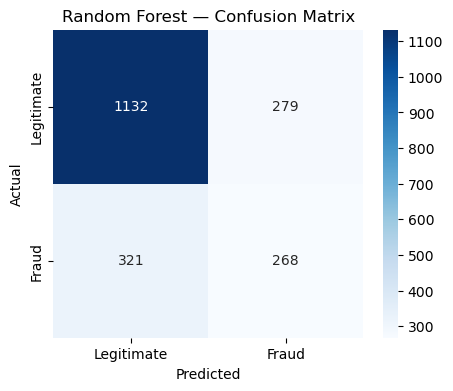

In [31]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# NOTE:
Random Forest achieved an accuracy of 70% and a ROC-AUC of 0.72, however it 
recorded a low recall of 45.50%, meaning it missed 321 actual fraudulent 
transactions — making it worse than Logistic Regression at catching fraud 
despite a slightly higher accuracy, and therefore not yet sufficient for 
NexaBank's fraud detection needs.

## 4.3 XGBoost

In [33]:
# XGBoost training 
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [34]:
# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [35]:
# Evaluation
print("XGBoost Results:")
print("------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("------------------------------")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
------------------------------
Accuracy:  0.7065
Precision: 0.5021
Recall:    0.4109
F1 Score:  0.4519
ROC-AUC:   0.7056
------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80      1411
           1       0.50      0.41      0.45       589

    accuracy                           0.71      2000
   macro avg       0.64      0.62      0.63      2000
weighted avg       0.69      0.71      0.70      2000



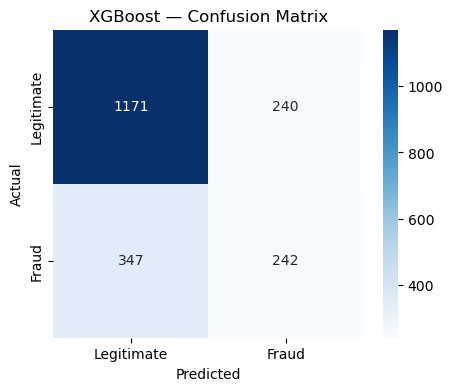

In [36]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# NOTE:
XGBoost achieved an accuracy of 70.65% and a ROC-AUC of 0.7056, but recorded 
the lowest recall of 41.09% among all three models, missing 347 actual fraudulent 
transactions — indicating that despite being a powerful algorithm, XGBoost 
underperformed compared to Logistic Regression for NexaBank's fraud detection 
task without further hyperparameter tuning.

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.6715     0.4639  0.7419    0.5709   0.7399
Random Forest          0.7000     0.4899  0.4550    0.4718   0.7211
XGBoost                0.7065     0.5021  0.4109    0.4519   0.7056


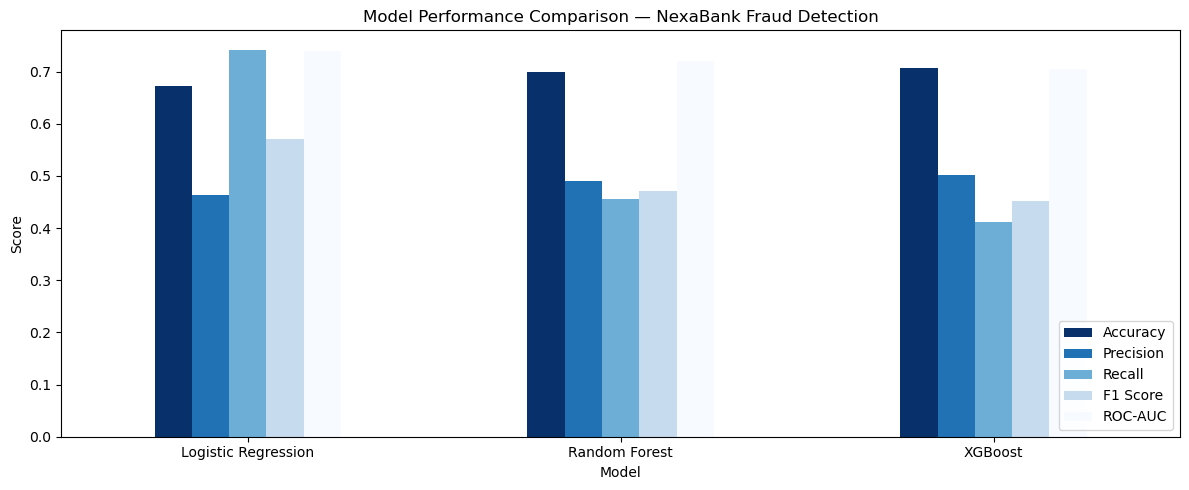

In [37]:
# Model Comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy':  [0.6715, 0.7000, 0.7065],
    'Precision': [0.4639, 0.4899, 0.5021],
    'Recall':    [0.7419, 0.4550, 0.4109],
    'F1 Score':  [0.5709, 0.4718, 0.4519],
    'ROC-AUC':   [0.7399, 0.7211, 0.7056]
})

comparison.set_index('Model', inplace=True)
print(comparison)

# Visual comparison
comparison.plot(kind='bar', figsize=(12, 5), colormap='Blues_r')
plt.title('Model Performance Comparison — NexaBank Fraud Detection')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

###  Model Comparison and Selection

Logistic Regression emerged as the best performing model for NexaBank's fraud 
detection task, achieving the highest Recall (0.74), F1 Score (0.57), and 
ROC-AUC (0.74) — meaning it correctly identified the most fraudulent transactions 
while maintaining a reasonable balance between precision and recall, making it 
the most suitable model for protecting NexaBank customers from fraud.

# 5.Hyper-Tuning Logistic Regression

Hyperparameter tuning is the process of finding the best configuration settings 
for a machine learning model that cannot be learned from the data itself, in order 
to optimise model performance on a given task.

Best Parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall Score: 0.7724

Tuned Logistic Regression Results:
------------------------------
Accuracy:  0.6610
Precision: 0.4568
Recall:    0.7980
F1 Score:  0.5810
ROC-AUC:   0.7009
------------------------------


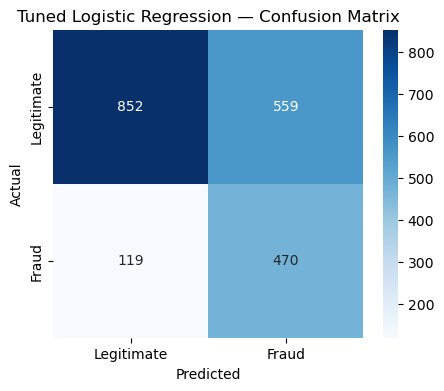

In [39]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Grid Search
grid_search = GridSearchCV(LogisticRegression(random_state=42),
                           param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Recall Score:", grid_search.best_score_.round(4))

# Evaluate tuned model
best_lr = grid_search.best_estimator_
y_pred_tuned = best_lr.predict(X_test)
y_prob_tuned = best_lr.predict_proba(X_test)[:,1]

print("\nTuned Logistic Regression Results:")
print("------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("------------------------------")

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Tuned Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# NOTE:
After tuning, the best parameters were C=0.001 and penalty=l1, which improved 
Recall from 0.74 to 0.80 — meaning the model now correctly identifies 80% of 
all fraudulent transactions — making it a stronger fraud detection model for 
NexaBank, though precision slightly decreased as the model now flags more 
transactions as fraud to catch more real cases.

# 6. Feature Importance — SHAP Analysis

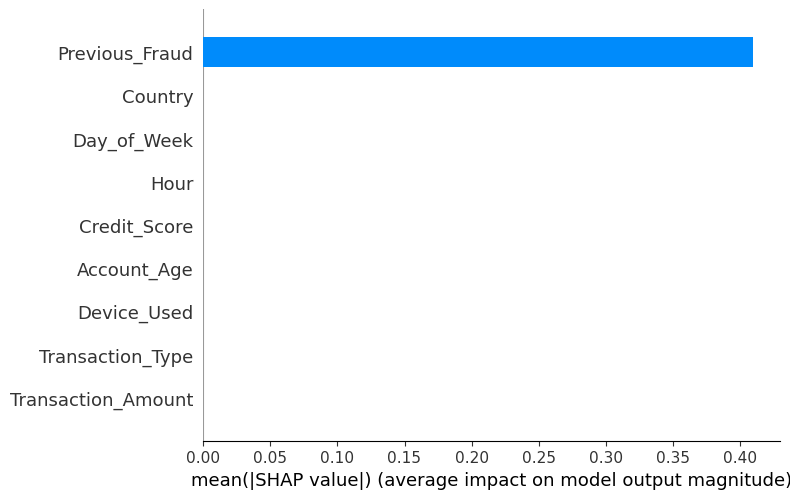

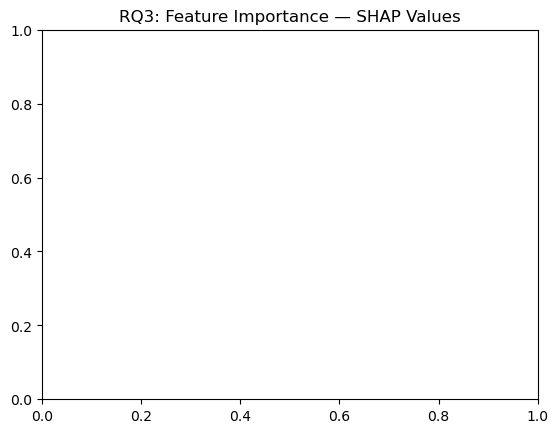

In [40]:
import shap

# SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(best_lr, X_train)
shap_values = explainer.shap_values(X_test)

# Get feature names
feature_names = bf.drop(columns=['Is_Fraud']).columns.tolist()

# SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  feature_names=feature_names, 
                  plot_type='bar',
                  show=True)
plt.title('RQ3: Feature Importance — SHAP Values')
plt.show()

# Note:
- Previous_Fraud is by far the most influential feature in the model, 
  confirming that customers with a prior fraud history are significantly 
  more likely to have a current fraudulent transaction at NexaBank.
- Country, Day_of_Week, and Hour have minimal but measurable impact, 
  suggesting that geographic and time-based patterns contribute slightly 
  to fraud prediction.
- Credit_Score, Account_Age, Device_Used, Transaction_Type, and 
  Transaction_Amount have very low SHAP values, indicating they contribute 
  least to the model's fraud predictions in their current form.
- Overall, Previous_Fraud dominates the model's decision making, which 
  is a strong actionable insight — NexaBank should flag and closely monitor 
  all transactions from customers with a prior fraud history.